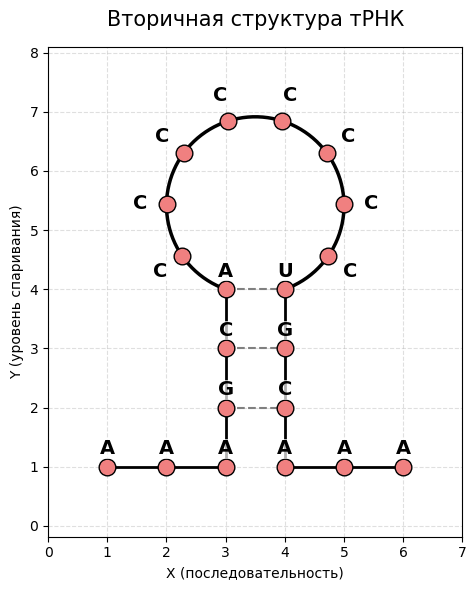

In [2]:
import matplotlib.pyplot as plt
import numpy as np

LOOP_RADIUS = 1.5  # Фиксированный радиус петли.

def get_loop_start_indices(dot_bracket: str) -> list:
    """Находит индексы первых нуклеотидов в петлях."""
    loop_starts = []
    i = 0
    n = len(dot_bracket)
    while i < n:
        if dot_bracket[i] == '.':
            j = i
            while j < n and dot_bracket[j] == '.':
                j += 1
            if i > 0 and j < n and dot_bracket[i-1] == '(' and dot_bracket[j] == ')':
                loop_starts.append(i)
            i = j
        else:
            i += 1
    return loop_starts

def generate_coordinates(dot_bracket: str, loop_starts: list) -> tuple:
    """Генерирует координаты с выравниванием хвоста под стеблем."""
    x_coords, y_coords = [], []
    level_x = 0.0
    level_y = 1
    prev_char = ''
    is_right_strand = False
    stem_x_left = 0.0

    for i, char in enumerate(dot_bracket):
        if char == '(':
            if not is_right_strand:
                stem_x_left = level_x
            level_y += 1
            x_coords.append(stem_x_left)
        elif char == ')':
            level_y -= 1
            x_coords.append(stem_x_left + 1.0)
            is_right_strand = True
            # Фиксируем курсор на правой границе стебля
            level_x = stem_x_left + 1.0
        elif char == '.':
            if i in loop_starts:
                level_y += 1
                x_coords.append(stem_x_left) # Временная координата, будет заменена дугой
            elif prev_char == ')':
                # ПЕРВАЯ точка после стебля: спускаемся вниз, НО X не меняем!
                level_y -= 1
                # Принудительно держим X на границе стебля
                level_x = stem_x_left + 1.0
                x_coords.append(level_x)
            else:
                # Остальные точки хвоста: двигаемся вправо
                level_x += 1
                x_coords.append(level_x)
        
        y_coords.append(level_y)
        prev_char = char
        
    return x_coords, y_coords

def find_base_pairs(dot_bracket: str) -> list:
    """Находит индексы комплементарных пар."""
    stack = []
    pairs = []
    for i, char in enumerate(dot_bracket):
        if char == '(':
            stack.append(i)
        elif char == ')':
            if stack:
                pairs.append((stack.pop(), i))
    return pairs

def get_loop_bracket_ranges(dot_bracket: str) -> list:
    """Возвращает индексы СКОБОК, ограничивающих каждую петлю."""
    ranges = []
    i = 0
    n = len(dot_bracket)
    while i < n:
        if dot_bracket[i] == '(':
            j = i + 1
            while j < n and dot_bracket[j] == '.':
                j += 1
            if j < n and dot_bracket[j] == ')' and j > i + 1:
                ranges.append((i, j))
                i = j
            else:
                i += 1
        else:
            i += 1
    return ranges

def apply_arc_to_loops(x: list, y: list, loop_ranges: list, loop_radius: float) -> tuple:
    """Расставляет нуклеотиды по окружности с РАВНЫМ угловым шагом."""
    x_new, y_new = x.copy(), y.copy()
    for open_idx, close_idx in loop_ranges:
        x_o, y_o = x[open_idx], y[open_idx]
        x_c, y_c = x[close_idx], y[close_idx]
        
        dx = (x_c - x_o) / 2.0
        R = max(loop_radius, dx + 0.01)
        h = np.sqrt(R**2 - dx**2)
        cx = (x_o + x_c) / 2.0
        cy = y_o + h
        
        alpha = np.arcsin(h / R)
        theta_start = np.pi + alpha
        theta_end = -alpha
        
        num_dots = close_idx - open_idx - 1
        if num_dots > 0:
            step = (theta_end - theta_start) / (num_dots + 1)
            thetas = theta_start + step * (np.arange(num_dots) + 1)
            
            for k, dot_idx in enumerate(range(open_idx + 1, close_idx)):
                x_new[dot_idx] = cx + R * np.cos(thetas[k])
                y_new[dot_idx] = cy + R * np.sin(thetas[k])
            
    return x_new, y_new


# ==================== ПРИМЕР ИСПОЛЬЗОВАНИЯ ====================
if __name__ == "__main__":
    sequence = "AAAGCACCCCCCCCUGCAAA"
    db_notation = "...(((........)))..."

    loop_starts = get_loop_start_indices(db_notation)
    x, y = generate_coordinates(db_notation, loop_starts)
    pairs = find_base_pairs(db_notation)
    loop_ranges = get_loop_bracket_ranges(db_notation)

    x, y = apply_arc_to_loops(x, y, loop_ranges, LOOP_RADIUS)

    fig, ax = plt.subplots(figsize=(8, 6))

    # Пунктирные связи (длина = 1)
    for open_idx, close_idx in pairs:
        ax.plot([x[open_idx], x[close_idx]], [y[open_idx], y[close_idx]],
                color='gray', linestyle='--', linewidth=1.5, zorder=2)

    # Рисуем полные дуги петель
    for open_idx, close_idx in loop_ranges:
        x_o, y_o = x[open_idx], y[open_idx]
        x_c, y_c = x[close_idx], y[close_idx]
        dx = (x_c - x_o) / 2.0
        R = LOOP_RADIUS
        h = np.sqrt(R**2 - dx**2)
        cx = (x_o + x_c) / 2.0
        cy = y_o + h
        alpha = np.arcsin(h / R)
        
        theta_line = np.linspace(np.pi + alpha, -alpha, 100)
        ax.plot(cx + R*np.cos(theta_line), cy + R*np.sin(theta_line),
                color='black', lw=2.5, zorder=3)

    # Точки (нуклеотиды)
    ax.plot(x, y, 'o', markersize=12, markerfacecolor='lightcoral',
            markeredgecolor='black', zorder=4)

    # Прямые линии скелета
    for i in range(len(x) - 1):
        in_loop_range = any(o <= i and (i + 1) <= c for o, c in loop_ranges)
        if not in_loop_range:
            ax.plot([x[i], x[i+1]], [y[i], y[i+1]], color='black', lw=2, zorder=2)

    # Подписи нуклеотидов
    for i, (xi, yi) in enumerate(zip(x, y)):
        in_loop = any(o < i < c for o, c in loop_ranges)
        
        if in_loop:
            for o, c in loop_ranges:
                if o < i < c:
                    dx = (x[c] - x[o]) / 2.0
                    cx = (x[o] + x[c]) / 2.0
                    R = LOOP_RADIUS
                    h = np.sqrt(R**2 - dx**2)
                    cy = y[o] + h
                    break
            dx_vec, dy_vec = xi - cx, yi - cy
            dist = np.hypot(dx_vec, dy_vec)
            offset = 0.45
            txt_x = xi + (dx_vec / dist) * offset if dist > 0 else xi
            txt_y = yi + (dy_vec / dist) * offset if dist > 0 else yi
        else:
            txt_x, txt_y = xi, yi + 0.3
            
        ax.text(txt_x, txt_y, sequence[i], fontsize=14, fontweight='bold',
                ha='center', va='center', zorder=5,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.1))

    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_title("Вторичная структура тРНК", fontsize=15, pad=15)
    ax.set_xlabel("X (последовательность)")
    ax.set_ylabel("Y (уровень спаривания)")
    ax.set_aspect('equal', adjustable='box')
    ax.margins(0.2)
    plt.tight_layout()
    plt.show()